# DermaMNIST Classifier Training (Optimized)

This notebook trains a ResNet-50 classifier on the DermaMNIST dataset with the following fixes applied:

- **Class weights**: uses proper inverse-frequency weighting (`total / (num_classes * count_per_class)`)
- **LR scheduler**: `ReduceLROnPlateau.step()` receives the epoch-level validation loss, not a single batch loss
- **Evaluation**: `num_classes` is consistent (always derived from config, never hardcoded)
- **Metric instantiation**: `Accuracy` is created once per fold/run, not every epoch
- **Early stopping**: monitors validation loss correctly with configurable patience
- **Mixed precision**: uses `torch.amp` for faster training on CUDA
- **Reproducibility**: explicit `generator` for DataLoader workers

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os.path as osp
import copy

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchmetrics import Accuracy
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

from src.datasets import DatasetBuilder
from src.models.classifiers import SimpleCNNtorch, build_resnet50
from src.utils import seed_everything, get_config, load_model_weights

I0000 00:00:1775058526.675390   34523 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
SEED = 2025
seed_everything(SEED)
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Configuration & Data Loading

In [4]:
repo_path = '/teamspace/studios/this_studio/CF-Robustness-Benchmark'
config_path = osp.join(repo_path, 'configs/train_classifier_derma.yaml')
config = get_config(config_path)

# Derived constants (single source of truth)
NUM_CLASSES = config.data.num_classes
DEVICE = config.accelerator if torch.cuda.is_available() else 'cpu'
TASK = 'binary' if NUM_CLASSES == 2 else 'multiclass'

print(f"Device: {DEVICE} | Classes: {NUM_CLASSES} | Task: {TASK}")

Device: cpu | Classes: 2 | Task: binary


In [5]:
ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

print(f"Train: {len(ds_builder.train_dataset)} | Val: {len(ds_builder.val_dataset)} | Test: {len(ds_builder.test_dataset)}")

Train: 1548 | Val: 221 | Test: 443


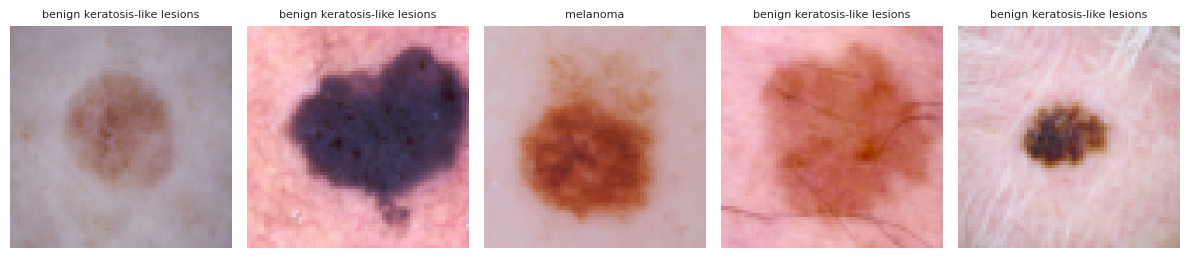

In [6]:
# Quick sanity check — visualize samples
# We need to un-normalize for display
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse ImageNet normalization for visualization. Input: (C, H, W) tensor."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1)

n_samples = 5
class_names = ds_builder.class_encodings
fig, axs = plt.subplots(1, n_samples, figsize=(12, 4))

sample_batch = next(iter(train_loader))
images, labels = sample_batch[0][:n_samples], sample_batch[1][:n_samples]

for i in range(n_samples):
    display_img = denormalize(images[i]).permute(1, 2, 0).numpy()
    axs[i].imshow(display_img)
    axs[i].set_title(class_names[labels[i].item()], fontsize=8)
    axs[i].axis('off')
plt.tight_layout()
plt.show()

## 2. Helper Functions

In [7]:
def setup_model(config, class_weights=None):
    """Build model, optimizer, loss, and lr_scheduler from config.
    
    Args:
        config: EasyDict configuration object.
        class_weights: Optional tensor of per-class weights for CrossEntropyLoss.
    
    Returns:
        Tuple of (model, optimizer, loss_fn, lr_scheduler).
    """
    # --- Model ---
    if config.classifier.name == 'resnet50':
        model = build_resnet50(config.data.num_classes)
    elif config.classifier.name == 'SimpleCNNTorch':
        model = SimpleCNNtorch(
            **config.classifier.args,
            num_classes=config.data.num_classes,
            img_size=config.data.img_size,
        )
    else:
        raise ValueError(f"Unknown classifier: {config.classifier.name}")

    # --- Loss (with optional class weights) ---
    loss_cls = getattr(nn, config.loss.name)
    loss_kwargs = dict(config.loss.args)
    if class_weights is not None:
        loss_kwargs['weight'] = class_weights
    loss_fn = loss_cls(**loss_kwargs)

    # --- Optimizer ---
    optimizer_cls = getattr(torch.optim, config.optimizer.name)
    # Optionally use differential learning rates:
    # lower lr for backbone, higher for head
    optimizer = optimizer_cls([
        {'params': model.fc.parameters(), 'lr': 1e-4},
        {'params': [p for n, p in model.named_parameters() 
                    if 'fc' not in n], 'lr': 1e-5},
    ])
    # optimizer = optimizer_cls(model.parameters(), **config.optimizer.args)

    # --- LR Scheduler ---
    lr_scheduler = None
    if config.lr_scheduler.enable:
        lr_scheduler_cls = getattr(torch.optim.lr_scheduler, config.lr_scheduler.name)
        lr_scheduler = lr_scheduler_cls(optimizer, **config.lr_scheduler.args)

    return model, optimizer, loss_fn, lr_scheduler

In [8]:
def compute_class_weights(dataset, num_classes, device='cpu'):
    """Compute inverse-frequency class weights: total / (num_classes * count_per_class).
    
    This gives higher weight to minority classes proportional to how underrepresented
    they are, which is the standard scikit-learn 'balanced' formula.
    """
    labels = dataset.data.labels.ravel()
    class_counts = np.bincount(labels, minlength=num_classes)
    total = labels.shape[0]

    # FIX: proper inverse-frequency weights (sklearn 'balanced' formula)
    weights = total / (num_classes * class_counts)
    weights = torch.tensor(weights, dtype=torch.float32).to(device)

    print("Class distribution:")
    for i, (count, w) in enumerate(zip(class_counts, weights)):
        print(f"  Class {i}: {count:>5d} samples  |  weight = {w:.4f}")

    return weights

In [9]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn, metric_fn, device):
    """Run a full evaluation pass. Returns (avg_loss, accuracy)."""
    model.eval()
    metric_fn.reset()
    total_loss = 0.0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        total_loss += loss_fn(logits, labels).item()
        preds = torch.argmax(logits, dim=1)
        metric_fn.update(preds, labels)

    avg_loss = total_loss / len(dataloader)
    accuracy = metric_fn.compute().item()
    return avg_loss, accuracy

## 3. Cross-Validation

In [ ]:
N_FOLDS = 5
CV_EPOCHS = 20
CV_PATIENCE = 3
CV_LR = 1e-3

# Override LR for CV experiments
config.optimizer.args['lr'] = CV_LR
config.optimizer.args['weight_decay'] = 0

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
dataset = ds_builder.train_dataset
all_labels = dataset.data.labels.ravel()

save_dir = osp.join(config.save_dir, 'multiclass/cv')
os.makedirs(save_dir, exist_ok=True) if not osp.exists(save_dir) else None

cv_results = {}

for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset, all_labels)):
    print(f"\n{'='*50}")
    print(f"Fold {fold + 1}/{N_FOLDS}")
    print(f"{'='*50}")

    # Fold data loaders
    g = torch.Generator().manual_seed(SEED + fold)
    fold_train_loader = DataLoader(
        Subset(dataset, train_idx), batch_size=config.batch_size, shuffle=True, generator=g
    )
    fold_val_loader = DataLoader(
        Subset(dataset, val_idx), batch_size=config.batch_size, shuffle=False
    )

    # Fresh model per fold
    model, optimizer, loss_fn, lr_scheduler = setup_model(config)
    model = model.to(DEVICE)
    loss_fn = loss_fn.to(DEVICE) if hasattr(loss_fn, 'to') else loss_fn

    # FIX: single metric instance per fold, not re-created every epoch
    val_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES).to(DEVICE)

    best_val_loss = float('inf')
    best_model_wts = None
    epochs_no_improve = 0

    for epoch in range(CV_EPOCHS):
        # --- Training ---
        model.train()
        epoch_train_loss = 0.0

        for batch in fold_train_loader:
            inputs, targets = batch[0].to(DEVICE), batch[1].to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            batch_loss = loss_fn(outputs, targets)
            batch_loss.backward()
            optimizer.step()
            epoch_train_loss += batch_loss.item()

        avg_train_loss = epoch_train_loss / len(fold_train_loader)

        # --- Validation ---
        val_loss, val_acc = evaluate(model, fold_val_loader, loss_fn, val_metric, DEVICE)

        # FIX: lr_scheduler.step() receives the epoch-level val loss
        if lr_scheduler is not None:
            lr_scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"  Epoch {epoch+1:>2d}/{CV_EPOCHS} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"lr={current_lr:.1e}"
        )

        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= CV_PATIENCE:
                print(f"  Early stopping at epoch {epoch + 1}")
                break

    cv_results[fold] = best_val_loss
    torch.save(best_model_wts, osp.join(save_dir, f'model_fold_{fold}.pth'))

print(f"\nCV Results: {cv_results}")
print(f"Mean val loss: {np.mean(list(cv_results.values())):.4f} ± {np.std(list(cv_results.values())):.4f}")

In [ ]:
# Evaluate the best fold on the held-out test set
best_fold = min(cv_results, key=cv_results.get)
print(f"Best fold: {best_fold} (val_loss={cv_results[best_fold]:.4f})")

weights_path = osp.join(save_dir, f'model_fold_{best_fold}.pth')
model, _, loss_fn, _ = setup_model(config)
model.load_state_dict(torch.load(weights_path, weights_only=True))
model.eval()

# FIX: always use NUM_CLASSES (from config), never a hardcoded value
test_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES)
test_loss, test_acc = evaluate(model, test_loader, loss_fn, test_metric, device='cpu')
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.3%}")

## 4. Full Training (with class-weighted loss)

In [10]:
# Reset config LR for full training run
# config.optimizer.args['lr'] = 1e-4
# config.optimizer.args['weight_decay'] = 0

# FIX: proper inverse-frequency class weights
class_weights = compute_class_weights(ds_builder.train_dataset, NUM_CLASSES, device=DEVICE)

model, optimizer, loss_fn, lr_scheduler = setup_model(config, class_weights=class_weights)
model = model.to(DEVICE)

Class distribution:
  Class 0:   769 samples  |  weight = 1.0065
  Class 1:   779 samples  |  weight = 0.9936


In [11]:
PATIENCE = 5
USE_AMP = DEVICE == 'cuda'  # mixed precision only on CUDA

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
val_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES).to(DEVICE)

training_info = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

for epoch in tqdm(range(config.epochs), desc="Training"):

    # ---- Training ----
    model.train()
    epoch_train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(images)
            batch_loss = loss_fn(logits, labels)

        scaler.scale(batch_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += batch_loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    training_info['train_loss'].append(avg_train_loss)

    # ---- Validation ----
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, val_metric, DEVICE)
    training_info['val_loss'].append(val_loss)
    training_info['val_acc'].append(val_acc)

    # FIX: scheduler steps on epoch-level validation loss
    if lr_scheduler is not None:
        lr_scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch {epoch+1:>2d}/{config.epochs} | "
        f"train_loss={avg_train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"lr={current_lr:.1e}"
    )

    # ---- Early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

# Restore best weights
model.load_state_dict(best_model_wts)
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Training:   0%|          | 0/30 [00:00<?, ?it/s]

Training:   3%|▎         | 1/30 [00:11<05:44, 11.89s/it]

Epoch  1/30 | train_loss=0.6898 | val_loss=0.6700 | val_acc=0.5882 | lr=1.0e-04


Training:   7%|▋         | 2/30 [00:24<05:47, 12.41s/it]

Epoch  2/30 | train_loss=0.6679 | val_loss=0.6442 | val_acc=0.6471 | lr=1.0e-04


...

Epoch 13/30 | train_loss=0.5467 | val_loss=0.5872 | val_acc=0.7285 | lr=1.0e-04


Training:  47%|████▋     | 14/30 [02:48<03:12, 12.03s/it]

Epoch 14/30 | train_loss=0.5488 | val_loss=0.5792 | val_acc=0.7557 | lr=1.0e-05


Training:  47%|████▋     | 14/30 [03:00<03:26, 12.91s/it]

Epoch 15/30 | train_loss=0.5330 | val_loss=0.6151 | val_acc=0.7285 | lr=1.0e-05
Early stopping at epoch 15

Training complete. Best val loss: 0.5620


## 5. Evaluation & Visualization

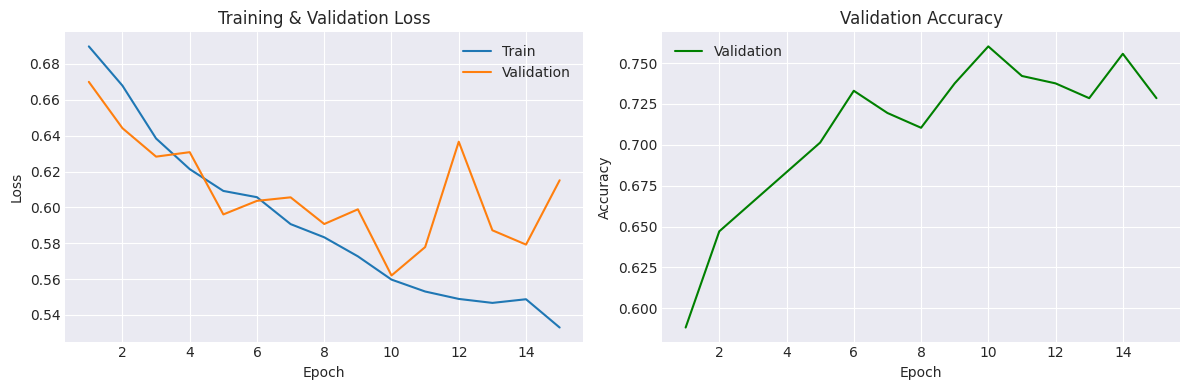

In [12]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(training_info['train_loss']) + 1)
ax1.plot(epochs_range, training_info['train_loss'], label='Train')
ax1.plot(epochs_range, training_info['val_loss'], label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()

ax2.plot(epochs_range, training_info['val_acc'], label='Validation', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [13]:
# FIX: always use NUM_CLASSES (derived from config), not a hardcoded 2 or 4
model_cpu = model.to('cpu')
model_cpu.eval()

test_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES)
test_loss_fn = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model_cpu, test_loader, test_loss_fn, test_metric, device='cpu')
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.3%}")

Test loss: 0.5973 | Test accuracy: 72.235%


In [14]:
# Save the best model
save_path = osp.join(
    config.save_dir,
    f'checkpoints/derma_resnet50_acc={test_acc:.2f}.pth'
)
os.makedirs(osp.dirname(save_path), exist_ok=True) if not osp.exists(osp.dirname(save_path)) else None
torch.save(model_cpu.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /teamspace/studios/this_studio/CF-Robustness-Benchmark/notebooks/experiments/dermamnist_classification/binary/checkpoints/derma_resnet50_acc=0.72.pth


In [15]:
# Load and verify saved model
model_verify, _, _, _ = setup_model(config)
model_verify.load_state_dict(torch.load(save_path, weights_only=True))
model_verify.eval()

verify_metric = Accuracy(task=TASK, num_classes=NUM_CLASSES)
_, verify_acc = evaluate(model_verify, test_loader, test_loss_fn, verify_metric, device='cpu')
print(f"Verification accuracy: {verify_acc:.3%}")
assert abs(verify_acc - test_acc) < 1e-6, "Saved model does not match!"

Verification accuracy: 72.235%
